In [ ]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing    import LabelEncoder
from sklearn.utils            import compute_class_weight
from sklearn.model_selection  import StratifiedKFold
from xgboost                  import XGBRegressor
from sklearn.decomposition import PCA

from skopt                    import BayesSearchCV

In [ ]:
df = pd.read_pickle('df_final_embeddings.pkl') # dtaaframe z embeddingami

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2491 entries, Inception to Theater Camp
Columns: 230 entries, adult to overview_embedding
dtypes: bool(1), category(1), float64(2), int64(224), object(2)
memory usage: 4.4+ MB


In [ ]:
for col in df.select_dtypes(include=['bool']).columns:
    df[col] = df[col].astype(int)

In [ ]:
df.drop(columns='label', inplace=True)

In [ ]:
def unpack_embedding_column(df: pd.DataFrame, col_name: str, prefix: str) -> pd.DataFrame:
    """
    Rozpakuj kolumnę embeddingów (lista lub np.array) na osobne kolumny.
    Jeśli wartość jest NaN lub nie-listą, zastępujemy wektorem zer.
    """
    # znajdź wymiar embeddingu na podstawie pierwszego niepustego rekordu
    non_null = df[col_name].dropna()
    if len(non_null) == 0:
        # brak żadnych embeddingów
        return pd.DataFrame(index=df.index)
    first = non_null.iloc[0]
    emb_dim = len(first) if isinstance(first, (list, np.ndarray)) else 0

    # zastąp pustki zerami i stwórz DataFrame z list
    emb_series = df[col_name].apply(
        lambda x: x if isinstance(x, (list, np.ndarray)) else [0]*emb_dim
    )
    emb_df = pd.DataFrame(emb_series.tolist(), index=df.index)
    emb_df.columns = [f"{prefix}_{i}" for i in range(emb_df.shape[1])]
    return emb_df

In [ ]:
if 'overview_embedding' in df.columns:
    overview_emb_df = unpack_embedding_column(df, 'overview_embedding', 'overview_emb')
else:
    overview_emb_df = pd.DataFrame(index=df.index)

if 'keywords_embedding' in df.columns:
    keywords_emb_df = unpack_embedding_column(df, 'keywords_embedding', 'keywords_emb')
else:
    keywords_emb_df = pd.DataFrame(index=df.index)

In [ ]:
df = df.drop(columns=[c for c in ['overview_embedding','keywords_embedding'] if c in df.columns])
df = pd.concat([df, overview_emb_df, keywords_emb_df], axis=1)

In [ ]:
feature_cols = [
    col for col in df.columns
    if col not in ['target_value']
]
X = df[feature_cols]

In [ ]:
y = df['target_value']

In [ ]:
emb_cols = [c for c in X.columns if 'emb_' in c]
other_cols = [c for c in X.columns if c not in emb_cols]

In [ ]:
len(emb_cols)

2048

In [ ]:
X_emb = X[emb_cols].values
# reduce to 200 dims ~ 85 % wariancji
pca = PCA(n_components=200, random_state=42)
X_emb_pca = pca.fit_transform(X_emb)

In [ ]:
X_other = X[other_cols].values
X_proc = np.concatenate([X_emb_pca, X_other], axis=1)

In [ ]:
X = X_proc

In [ ]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [ ]:
xgb_reg = XGBRegressor(
    objective='reg:squarederror',  # Objective for regression
    eval_metric='rmse',            # Evaluation metric for regression
    n_jobs=-1,
    random_state=42
)

In [ ]:
# Define the parameter space for the regressor.
# Use a similar structure to the classifier's parameter space.
# Adjust ranges as needed for regression.
param_space_reg = {
    'max_depth'        : (3, 6),
    'learning_rate'    : (0.01, 0.3, 'log-uniform'),
    'n_estimators'     : (50, 200),
    'subsample'        : (0.5, 0.7, 'uniform'),
    'colsample_bytree' : (0.1, 0.3, 'uniform'),
    'gamma'            : (0, 1, 'uniform'),
    'min_child_weight' : (1, 5),
    'reg_alpha'        : (1e-8, 1e-1, 'log-uniform'),
    'reg_lambda'       : (1e-8, 1.0, 'log-uniform'),
}

In [ ]:
# Set up BayesSearchCV for the regressor
# Note: We don't use StratifiedKFold for regression, use standard KFold or leave it as default (which is KFold)
# We also don't use sample_weight calculated based on class balance for regression.
# The scoring metric should be appropriate for regression, e.g., 'neg_mean_squared_error' or 'r2'.
# Let's use 'neg_mean_squared_error' as it's common for optimization (higher is better, so minimize MSE).

from sklearn.model_selection import KFold

cv_reg = KFold(
    n_splits=3,  # Using same number of splits as before
    shuffle=True,
    random_state=42
)


bayes_search_reg = BayesSearchCV(
    estimator     = xgb_reg,
    search_spaces = param_space_reg,
    n_iter        = 10,  # Using same number of iterations
    cv            = cv_reg, # Using KFold for regression
    scoring       = 'neg_mean_squared_error', # Scoring for regression
    n_jobs        = -1,
    refit         = True,
    verbose       = 1
)

In [ ]:
# Prepare X and y for regression

# Convert 'target_value' to numeric, coercing errors to NaN and then dropping NaNs
y_reg = pd.to_numeric(df['target_value'], errors='coerce')
# Drop rows where 'target_value' is NaN after conversion
df_reg = df.loc[y_reg.dropna().index].copy()
y_reg = y_reg.dropna()

# Redefine feature columns for regression, excluding original 'label' and 'target_value'
feature_cols_reg = [
    col for col in df_reg.columns
    if col not in ['label', 'target_value']
]
X_reg_df = df_reg[feature_cols_reg]

# Separate embedding and other columns
emb_cols_reg = [c for c in X_reg_df.columns if 'emb_' in c]
other_cols_reg = [c for c in X_reg_df.columns if c not in emb_cols_reg]

# Apply PCA to embedding columns
if len(emb_cols_reg) > 0:
    X_reg_emb = X_reg_df[emb_cols_reg].values
    # Assuming you want to train a new PCA on the regression feature set embeddings
    pca_reg = PCA(n_components=200, random_state=42)
    X_reg_emb_pca = pca_reg.fit_transform(X_reg_emb)
    X_reg_other = X_reg_df[other_cols_reg].values
    X_reg_proc = np.concatenate([X_reg_emb_pca, X_reg_other], axis=1)
else:
    X_reg_proc = X_reg_df.values

print("Shape of X for regression:", X_reg_proc.shape)
print("Shape of y for regression:", y_reg.shape)

# Perform the Bayesian optimization for the regressor
# Use X_reg_proc and y_reg
bayes_search_reg.fit(X_reg_proc, y_reg)

print("\nNajlepsze parametry (Regressor):", bayes_search_reg.best_params_)
print("Najlepszy CV (ujemny MSE - Regressor):", bayes_search_reg.best_score_)
# To get the actual MSE, negate the best_score_
print("Najlepszy CV MSE (Regressor):", -bayes_search_reg.best_score_)

Shape of X for regression: (2491, 426)
Shape of y for regression: (2491,)
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits

Najlepsze parametry (Regressor): OrderedDict([('colsample_bytree', 0.21431612889883894), ('gamma', 0), ('learning_rate', 0.04071221764263813), ('max_depth', 4), ('min_child_weight', 5), ('n_estimators', 100), ('reg_alpha', 0.001101135666974076), ('reg_lambda', 6.040725209720601e-08), ('subsample', 0.550953456382961)])
Najlepszy CV (u

In [ ]:
print("\nNajlepsze parametry:", bayes_search_reg.best_params_)
print("Najlepszy CV (ujemny MSE - Regressor):", bayes_search_reg.best_score_)


Najlepsze parametry: OrderedDict([('colsample_bytree', 0.21431612889883894), ('gamma', 0), ('learning_rate', 0.04071221764263813), ('max_depth', 4), ('min_child_weight', 5), ('n_estimators', 100), ('reg_alpha', 0.001101135666974076), ('reg_lambda', 6.040725209720601e-08), ('subsample', 0.550953456382961)])
Najlepszy CV (ujemny MSE - Regressor): -1.5248502040853775


In [ ]:
# prompt: wygeneruj macierz pomyłek

from sklearn.metrics import mean_squared_error, root_mean_squared_error
import matplotlib.pyplot as plt # Keep import in case of future plots

# Predict on the entire dataset with the best model found
# Use X_reg_proc which was used to train the regressor
y_pred_reg = bayes_search_reg.predict(X_reg_proc)

# Calculate regression evaluation metrics
mse = mean_squared_error(y_reg, y_pred_reg)
rmse = root_mean_squared_error(y_reg, y_pred_reg)


print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# Note: Confusion matrix is not applicable for regression tasks.
# The following lines are commented out as they are for classification.
# # Generate the confusion matrix
# cm = confusion_matrix(y, y_pred)
#
# # Get the class labels
# class_labels = le.classes_
#
# # Display the confusion matrix
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
# disp.plot(cmap=plt.cm.Blues)
# plt.title('Macierz Pomyłek')
# plt.show()

Mean Squared Error (MSE): 1.0364
Root Mean Squared Error (RMSE): 1.0180


In [ ]:
# prompt: pokaz najwazniejsze miary dobroci tego modelu

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Evaluate the model
# accuracy = accuracy_score(y, y_pred) # Not applicable for regression
# precision = precision_score(y, y_pred, average='macro') # Not applicable for regression
# recall = recall_score(y, y_pred, average='macro') # Not applicable for regression
# f1 = f1_score(y, y_pred, average='macro') # Not applicable for regression

# print(f"\nDokładność (Accuracy): {accuracy:.4f}")
# print(f"Precyzja (Precision - Macro): {precision:.4f}")
# print(f"Czułość (Recall - Macro): {recall:.4f}")
# print(f"Wynik F1 (F1-score - Macro): {f1:.4f}")

# Detailed classification report
# print("\nSzczegółowy raport klasyfikacji:") # Not applicable for regression
# print(classification_report(y, y_pred, target_names=class_labels)) # Not applicable for regression

# Since this cell was intended to show important metrics, and we've calculated
# MSE and RMSE in the previous cell, we can reiterate those or add other regression metrics here if needed.
# However, given the error was related to classification metrics, removing them is the primary fix.

print("Metryki klasyfikacji nie mają zastosowania dla modelu regresyjnego.")
print("Wcześniej obliczone metryki regresji to:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Metryki klasyfikacji nie mają zastosowania dla modelu regresyjnego.
Wcześniej obliczone metryki regresji to:
Mean Squared Error (MSE): 1.0364
Root Mean Squared Error (RMSE): 1.0180


In [42]:
# prompt: podaj miary mae, rmse, r2, mse

from sklearn.metrics import mean_absolute_error, r2_score

# Calculate MAE
mae = mean_absolute_error(y_reg, y_pred_reg)

# Calculate R2
r2 = r2_score(y_reg, y_pred_reg)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# You can also print the previously calculated MSE and RMSE again for completeness
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


Mean Absolute Error (MAE): 0.7994
R-squared (R2): 0.3545
Mean Squared Error (MSE): 1.0364
Root Mean Squared Error (RMSE): 1.0180


In [43]:
!pip install shap

In [45]:
import shap

# Create an explainer object using the best model from BayesSearchCV
explainer = shap.TreeExplainer(bayes_search_reg.best_estimator_)

# Calculate SHAP values for the entire dataset X
# Note: This might take some time depending on the size of your dataset
shap_values = explainer.shap_values(X_reg_proc)

# Get the feature names from the original DataFrame (excluding the target columns)
# Use the feature columns that were used to create X_reg_proc
feature_names = X_reg_df.columns.tolist()


Generating SHAP Summary Plot...


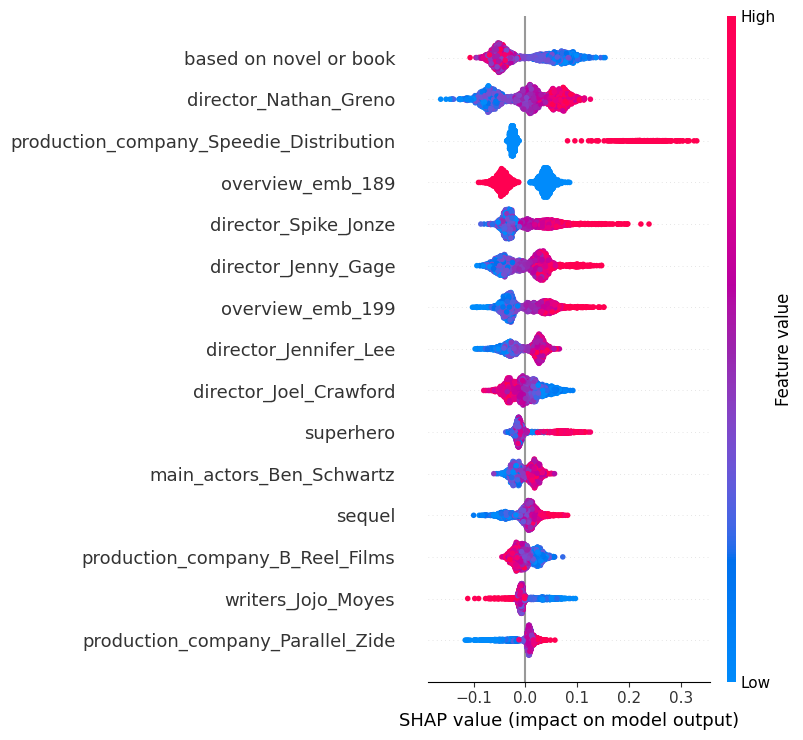

In [47]:
# Visualize the top 15 most important features using a SHAP summary plot

# SHAP values for regression are typically a single array
# Check the shape of shap_values to be sure, it should be (n_samples, n_features)
# If it's a list of arrays (for multi-output regression), we might need to adjust

# Assuming shap_values is (n_samples, n_features) for single-output regression
# Use feature_names which were extracted from X_reg_df

# Create a Summary Plot
print("\nGenerating SHAP Summary Plot...")
shap.summary_plot(shap_values, X_reg_proc, feature_names=feature_names, max_display=15)

# Note: Confusion matrix and classification report are not applicable for regression tasks.
# The original code for these metrics has been removed.

In [ ]:
print(f"Shape of shap_values: {len(shap_values)}")
print(f"Shape of shap_values[0]: {shap_values[0].shape}")

Shape of shap_values: 2491
Shape of shap_values[0]: (2274, 4)


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error



# Drop the original 'label' column as we'll predict a continuous target
# Assuming your regression target is in a column named 'target_regression'
# If your target is different, please adjust the column name below
# For this example, let's assume the original 'target_value' column dropped earlier was the regression target
# If you need a different target, you'll need to load or derive it.
# For now, I will assume we need to use the 'vote_average' column as a regression target for this example.
# If you have a different target variable, please replace 'vote_average' with your target column name.

# Let's re-prepare X and define the regression target y_reg
# Need to make sure 'vote_average' was not dropped in previous steps.
# Based on df.info() output, 'vote_average' is likely one of the float64 columns.
# Let's confirm it exists and use it as the target.

if 'vote_average' in df.columns:
    y_reg = df['vote_average']
    # X is already prepared excluding the original 'label' column
    # However, if 'vote_average' was part of X, we need to drop it from X
    if 'vote_average' in feature_cols:
         X_reg = df[feature_cols].drop(columns=['vote_average'])
         # Re-apply PCA if necessary, or use the existing X_proc if 'vote_average' was not in original features
         # Given the prompt asks for similar technology, let's assume we use the processed features X_proc,
         # ensuring 'vote_average' was not included in the original features used for classification X.
         # Checking the feature_cols definition: it includes all columns except 'label'.
         # If 'vote_average' was in df, it was in feature_cols and thus in X.
         # So we need to drop it from X_proc as well for regression.

         # Let's regenerate X_proc carefully for the regression task

         # Re-identify feature columns for regression, excluding the original 'label' and the new regression target
         feature_cols_reg = [
             col for col in df.columns
             if col not in ['label', 'vote_average'] # Exclude both original label and regression target
         ]
         X_reg_df = df[feature_cols_reg]

         # Separate embedding and other columns based on the regression feature list
         emb_cols_reg = [c for c in X_reg_df.columns if 'emb_' in c]
         other_cols_reg = [c for c in X_reg_df.columns if c not in emb_cols_reg]

         # Apply PCA to embedding columns if they exist
         if len(emb_cols_reg) > 0:
            X_reg_emb = X_reg_df[emb_cols_reg].values
            # Use the same PCA object if its state is relevant, or a new one if trained on regression features only
            # Given the goal is similar technology, let's assume we re-apply PCA on the regression feature set embeddings
            pca_reg = PCA(n_components=200, random_state=42) # Using same n_components as before
            X_reg_emb_pca = pca_reg.fit_transform(X_reg_emb)
            X_reg_other = X_reg_df[other_cols_reg].values
            X_reg_proc = np.concatenate([X_reg_emb_pca, X_reg_other], axis=1)
         else:
            # No embedding columns in the regression features
            X_reg_proc = X_reg_df.values


         print("Shape of X for regression:", X_reg_proc.shape)
         print("Shape of y for regression:", y_reg.shape)

else:
    print("Error: 'vote_average' column not found in the DataFrame.")
    # Handle the case where the target column is missing - maybe load a different file or ask user for target

In [ ]:
# Define the XGBoost Regressor model
xgb_reg = XGBRegressor(
    objective='reg:squarederror',  # Objective for regression
    eval_metric='rmse',            # Evaluation metric for regression
    n_jobs=-1,
    random_state=42
)

In [ ]:
# Define the parameter space for the regressor.
# Use a similar structure to the classifier's parameter space.
# Adjust ranges as needed for regression.
param_space_reg = {
    'max_depth'        : (3, 6),
    'learning_rate'    : (0.01, 0.3, 'log-uniform'),
    'n_estimators'     : (50, 200),
    'subsample'        : (0.5, 0.7, 'uniform'),
    'colsample_bytree' : (0.1, 0.3, 'uniform'),
    'gamma'            : (0, 1, 'uniform'),
    'min_child_weight' : (1, 5),
    'reg_alpha'        : (1e-8, 1e-1, 'log-uniform'),
    'reg_lambda'       : (1e-8, 1.0, 'log-uniform'),
}

In [ ]:
# Set up BayesSearchCV for the regressor
# Note: We don't use StratifiedKFold for regression, use standard KFold or leave it as default (which is KFold)
# We also don't use sample_weight calculated based on class balance for regression.
# The scoring metric should be appropriate for regression, e.g., 'neg_mean_squared_error' or 'r2'.
# Let's use 'neg_mean_squared_error' as it's common for optimization (higher is better, so minimize MSE).

from sklearn.model_selection import KFold

cv_reg = KFold(
    n_splits=3,  # Using same number of splits as before
    shuffle=True,
    random_state=42
)


bayes_search_reg = BayesSearchCV(
    estimator     = xgb_reg,
    search_spaces = param_space_reg,
    n_iter        = 10,  # Using same number of iterations
    cv            = cv_reg, # Using KFold for regression
    scoring       = 'neg_mean_squared_error', # Scoring for regression
    n_jobs        = -1,
    refit         = True,
    verbose       = 1
)

In [ ]:
# Perform the Bayesian optimization for the regressor
# Use X_reg_proc and y_reg
bayes_search_reg.fit(X_reg_proc, y_reg)

In [ ]:
print("\nNajlepsze parametry (Regressor):", bayes_search_reg.best_params_)
print("Najlepszy CV (ujemny MSE - Regressor):", bayes_search_reg.best_score_)
# To get the actual MSE, negate the best_score_
print("Najlepszy CV MSE (Regressor):", -bayes_search_reg.best_score_)

In [49]:
# Calculate the mean absolute SHAP value for each feature
# This gives a measure of the overall importance of each feature
mean_abs_shap_values = np.mean(np.abs(shap_values), axis=0)

# Construct feature names for the processed data (after PCA)
# The first 200 features are from the PCA of embeddings
pca_feature_names = [f'pca_emb_{i}' for i in range(pca_reg.n_components)]
# The remaining features are the other columns
processed_feature_names = pca_feature_names + other_cols_reg

# Check if the lengths match before creating the Series
if len(mean_abs_shap_values) != len(processed_feature_names):
    print(f"Error: Mismatch in lengths. SHAP values length: {len(mean_abs_shap_values)}, Processed feature names length: {len(processed_feature_names)}")
else:
    # Create a pandas Series with feature names as index and mean absolute SHAP values as values
    feature_importance = pd.Series(mean_abs_shap_values, index=processed_feature_names)

    # Sort the features by importance in descending order
    sorted_feature_importance = feature_importance.sort_values(ascending=False)

    # Print the names of the top 15 most important features
    print("Top 15 most important features:")
    print(sorted_feature_importance.head(15).index.tolist())

Top 15 most important features:
['pca_emb_1', 'pca_emb_16', 'sequel', 'genre_Drama', 'pca_emb_45', 'pca_emb_23', 'runtime_log', 'pca_emb_39', 'pca_emb_21', 'pca_emb_3', 'pca_emb_127', 'pca_emb_2', 'pca_emb_178', 'pca_emb_104', 'pca_emb_161']
